# Phase 1: Data Exploration & Sanity Checks

## What this notebook does

Before we touch any deep learning, we need to confirm the data we have is what the paper described, and that it's healthy enough to train on. Specifically:

1. Mount Google Drive so Colab can see our files
2. Load `data.csv` and confirm row counts, columns, and splits match the paper
3. Verify every image referenced in the CSV actually exists on disk
4. Open ~20 random images and look at them visually
5. Check the BMI distribution — paper says BMI ranges from underweight (~17) up to ~86
6. Sanity-check the train/test split: 3,368 train, 838 test
7. Quick check: do males/females have similar BMI distributions in train vs test? (If train is mostly thin and test is mostly heavy, our scores will be misleading.)

## Before you run this

- Upload `data.csv` to `MyDrive/face2bmi/data/data.csv`
- Upload all 4,206 `.bmp` images to `MyDrive/face2bmi/data/images/`
- Use a GPU runtime (Runtime → Change runtime type → GPU). Not strictly needed for this notebook, but you'll want it for Phase 2 and switching later wipes your variables.

## Cell 1: Mount Google Drive

When you run this cell, Colab pops up a window asking for permission to access your Drive. Approve it. After this, your Drive is visible at `/content/drive/MyDrive/`.

**What `drive.mount` does:** it tells Colab's filesystem to treat your Drive as a folder. Any reads/writes happen over the network, which is why it's slower than reading from local Colab disk. For loading the CSV (small) it's fine. For loading 4,206 images we'll address that in Phase 2.

In [14]:
from google.colab import drive
drive.mount('/content/drive')

# Define paths once at the top so we can change them in one place if folders move
PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/uChicago/ML/ML Final"
DATA_DIR = f'{PROJECT_ROOT}/Data'
IMAGES_DIR = f'{DATA_DIR}/Images'
CSV_PATH = f'{DATA_DIR}/data.csv'

print('Drive mounted.')
print('Project root:', PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.
Project root: /content/drive/MyDrive/Colab Notebooks/uChicago/ML/ML Final


## Cell 2: Load the CSV and look at it

Standard pandas. The `index_col=0` part is because the CSV's first column is an unnamed index (you saw `,bmi,gender,is_training,name` as the header — that leading comma means "the first column has no name and is the row index").

What we expect to see:
- 4,206 rows
- 4 columns: bmi, gender, is_training, name
- 3,368 train (`is_training=1`) and 838 test (`is_training=0`)
- ~2,438 male and ~1,768 female

In [11]:
import pandas as pd

df = pd.read_csv(CSV_PATH, index_col=0)

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 5 rows:')
print(df.head())
print('\nTrain/test counts:')
print(df['is_training'].value_counts())
print('\nGender counts:')
print(df['gender'].value_counts())
print('\nAny missing values?')
print(df.isnull().sum())

Shape: (4206, 4)

Columns: ['bmi', 'gender', 'is_training', 'name']

First 5 rows:
         bmi  gender  is_training       name
0  34.207396    Male            1  img_0.bmp
1  26.453720    Male            1  img_1.bmp
2  34.967561  Female            1  img_2.bmp
3  22.044766  Female            1  img_3.bmp
4  37.758789  Female            1  img_4.bmp

Train/test counts:
is_training
1    3368
0     838
Name: count, dtype: int64

Gender counts:
gender
Male      2438
Female    1768
Name: count, dtype: int64

Any missing values?
bmi            0
gender         0
is_training    0
name           0
dtype: int64


## Cell 3: Verify every image file exists

The CSV claims certain filenames exist. Let's check that each one is actually on disk. If 50 files are missing, you want to know now, not when training crashes halfway through.

**What `os.path.exists` does:** returns True/False for whether a path exists. We loop through every filename in the CSV and count how many are missing.

**Why I'm doing this with a list comprehension:** it's faster than a for-loop with `.append()`, and it produces a list we can directly stick back onto the dataframe as a new column. If you see any missing files, the dataframe will tell you *which* ones, not just how many.

In [12]:
import os

df['file_exists'] = [os.path.exists(f'{IMAGES_DIR}/{fname}') for fname in df['name']]

missing = df[~df['file_exists']]
print(f'Total images expected: {len(df)}')
print(f'Images found on disk: {df["file_exists"].sum()}')
print(f'Images missing: {len(missing)}')

if len(missing) > 0:
    print('\nFirst 10 missing files:')
    print(missing[['name', 'bmi', 'gender']].head(10))

Total images expected: 4206
Images found on disk: 0
Images missing: 4206

First 10 missing files:
        name        bmi  gender
0  img_0.bmp  34.207396    Male
1  img_1.bmp  26.453720    Male
2  img_2.bmp  34.967561  Female
3  img_3.bmp  22.044766  Female
4  img_4.bmp  37.758789  Female
5  img_5.bmp  24.886475  Female
6  img_6.bmp  25.845588  Female
7  img_7.bmp  21.740701  Female
8  img_8.bmp  30.615858  Female
9  img_9.bmp  26.788876  Female


## Cell 4: Open a sample image and inspect its properties

Now the actual visual sanity check. We'll load one image, print its dimensions and color mode, and display it. This tells us:

- **Size:** is it already a 224×224 face crop? Or a larger image we'd need to crop ourselves? (For VGG-Face we want 224×224 input eventually.)
- **Color mode:** RGB? Grayscale? RGBA with transparency? Any non-RGB images need conversion before feeding to a face model.
- **Visual content:** is it actually a face crop, or did the dataset come pre-cropped differently than expected?

**`PIL.Image.open`** is the standard Python way to open image files. It's lazy — it doesn't actually load pixels until you access them, which is why I call `.load()` to force it.

Filename: img_0.bmp
Image size (width x height): (164, 176)
Color mode: RGB
Format: BMP
BMI label: 34.2073961938
Gender label: Male


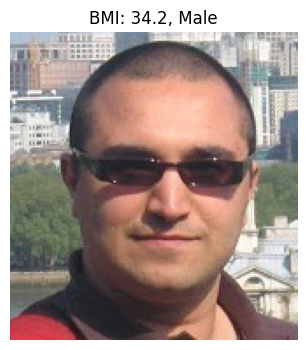

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

# Load the first image as a probe
sample_path = f'{IMAGES_DIR}/{df.iloc[0]["name"]}'
img = Image.open(sample_path)
img.load()

print('Filename:', df.iloc[0]['name'])
print('Image size (width x height):', img.size)
print('Color mode:', img.mode)  # 'RGB' is what we want
print('Format:', img.format)
print('BMI label:', df.iloc[0]['bmi'])
print('Gender label:', df.iloc[0]['gender'])

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.title(f"BMI: {df.iloc[0]['bmi']:.1f}, {df.iloc[0]['gender']}")
plt.show()

## Cell 5: Look at a 5x4 grid of random samples spanning BMI ranges

One image isn't enough. We want to see variety. This grid will:

- Pick 4 random images from each of 5 BMI buckets (normal, overweight, mod_obese, sev_obese, very_sev_obese)
- Display them with their BMI labels

**Why bucket-sampled instead of fully random?** Because if we just sample 20 random faces, we might miss whole BMI ranges (especially the rare ones like underweight). Bucketing forces us to see the full spectrum. This is the same logic behind "stratified sampling" — if your data has imbalance, random sampling reflects the imbalance, but for inspection purposes we want representation.

**`np.random.seed(42)`** makes the random selection reproducible — every time you run this cell you get the same images, which is useful when debugging.

In [20]:
import os

df['file_exists'] = [os.path.exists(f'{IMAGES_DIR}/{fname}') for fname in df['name']]

missing = df[~df['file_exists']]
print(f'Total images expected: {len(df)}')
print(f'Images found on disk: {df["file_exists"].sum()}')
print(f'Images missing: {len(missing)}')

if len(missing) > 0:
    print('\nFirst 10 missing files:')
    print(missing[['name', 'bmi', 'gender']].head(10))
else:
    print('\nAll images found!')


Total images expected: 4206
Images found on disk: 3962
Images missing: 244

First 10 missing files:
            name        bmi  gender
4      img_4.bmp  37.758789  Female
5      img_5.bmp  24.886475  Female
40    img_40.bmp  39.575905    Male
86    img_86.bmp  54.123702  Female
93    img_93.bmp  27.464398  Female
112  img_112.bmp  39.191165    Male
113  img_113.bmp  35.122878    Male
238  img_238.bmp  32.887057    Male
239  img_239.bmp  27.405881    Male
300  img_300.bmp  36.868444    Male


In [21]:
# Filter the DataFrame to keep only images that exist on disk
df_filtered = df[df['file_exists']].copy()

print(f'Original DataFrame shape: {df.shape}')
print(f'Filtered DataFrame shape (only existing files): {df_filtered.shape}')

df = df_filtered # Update the main DataFrame 'df' to use the filtered version for subsequent operations

Original DataFrame shape: (4206, 5)
Filtered DataFrame shape (only existing files): (3962, 5)


## Cell 5: Look at a 5x4 grid of random samples spanning BMI ranges (Re-run with filtered data)

Now that we've filtered out missing files, this cell should execute without `FileNotFoundError`.

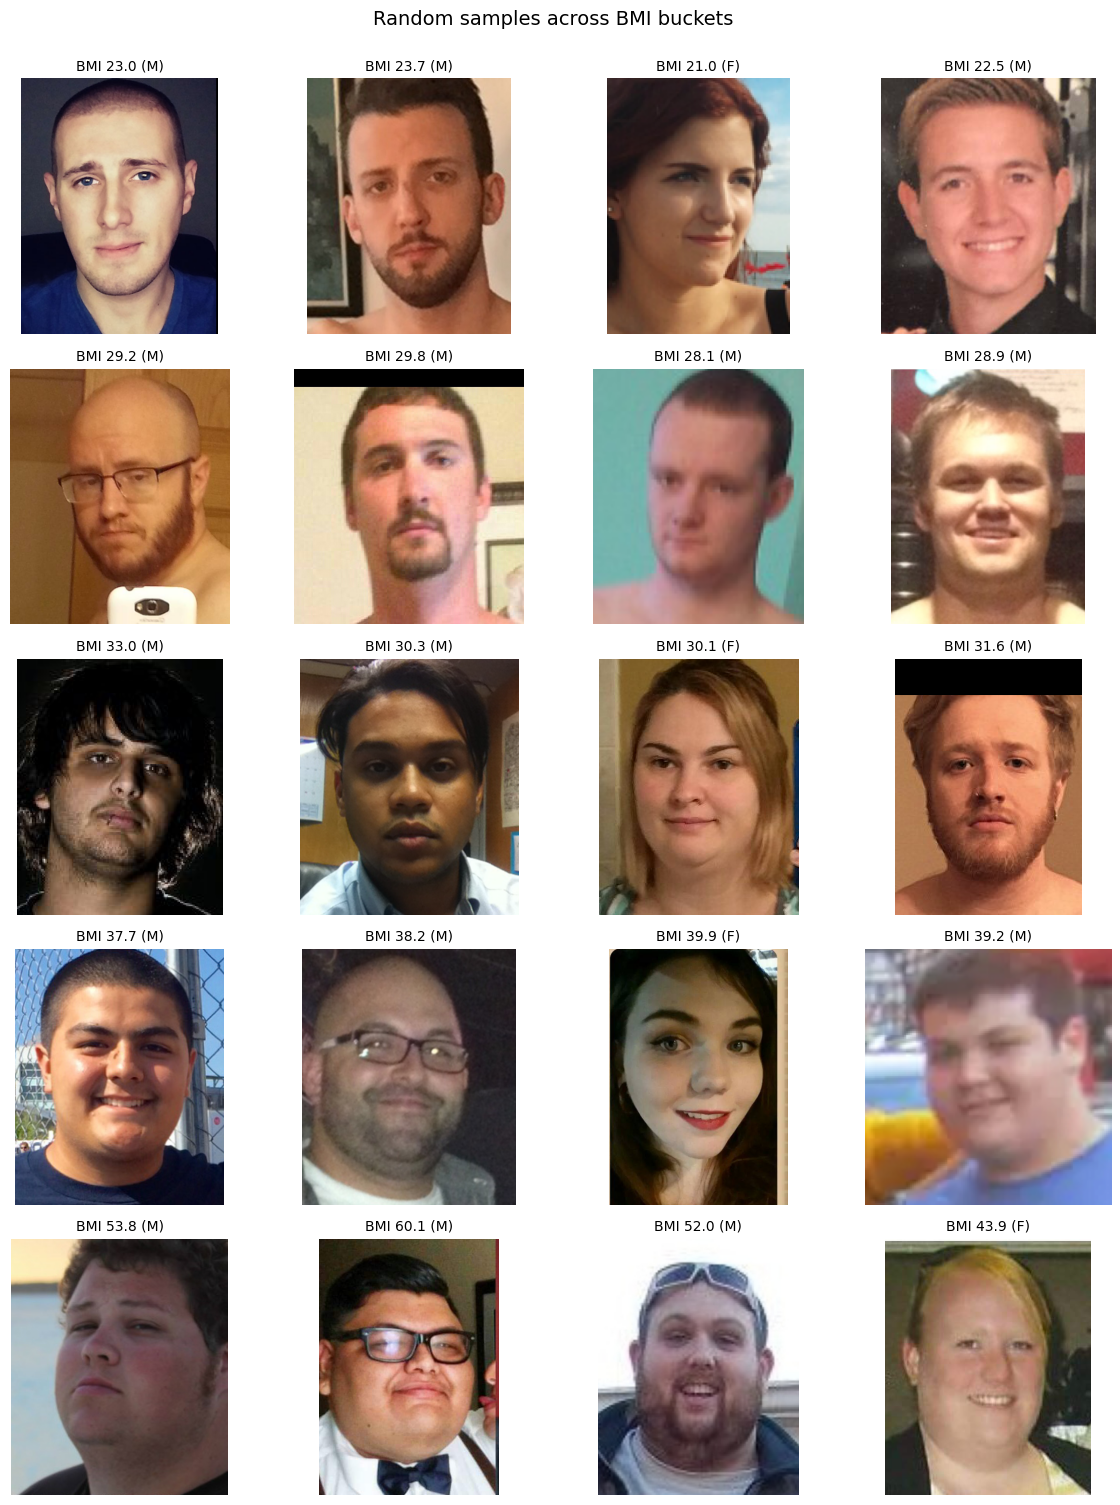

In [22]:
import numpy as np

np.random.seed(42)

# Define BMI buckets matching the paper's categories
buckets = [
    ('normal',         18.5, 25),
    ('overweight',     25,   30),
    ('mod_obese',      30,   35),
    ('sev_obese',      35,   40),
    ('very_sev_obese', 40,   100),
]

fig, axes = plt.subplots(5, 4, figsize=(12, 15))

for row_idx, (bucket_name, low, high) in enumerate(buckets):
    bucket_df = df[(df['bmi'] > low) & (df['bmi'] <= high)]
    # Ensure we don't try to sample more than available, especially if a bucket has few images
    n_samples = min(4, len(bucket_df))
    if n_samples == 0:
        print(f"Warning: No images found for {bucket_name} BMI bucket.")
        continue
    samples = bucket_df.sample(n=n_samples, random_state=42)

    for col_idx, (_, sample_row) in enumerate(samples.iterrows()):
        ax = axes[row_idx, col_idx]
        img = Image.open(f"{IMAGES_DIR}/{sample_row['name']}")
        ax.imshow(img)
        ax.set_title(f"BMI {sample_row['bmi']:.1f} ({sample_row['gender'][0]})", fontsize=10)
        ax.axis('off')

    # Add a label to the leftmost image in each row indicating the bucket
    if n_samples > 0: # Only add label if there were samples in this bucket
        axes[row_idx, 0].set_ylabel(bucket_name, fontsize=12, rotation=0, labelpad=60, va='center')
    else:
        axes[row_idx, 0].set_visible(False) # Hide axis if no samples

plt.suptitle('Random samples across BMI buckets', fontsize=14, y=1.0
)
plt.tight_layout()
plt.show()

## Cell 6: Check the BMI distribution

Two histograms side by side: train and test. We want them to look *similar*. If train is mostly normal-weight people and test is mostly obese, our model is going to look bad on test for reasons unrelated to its actual quality.

We'll also overlay a kernel density estimate (KDE), which is a smoothed version of the histogram. It's just a nicer way to compare the *shape* of two distributions.

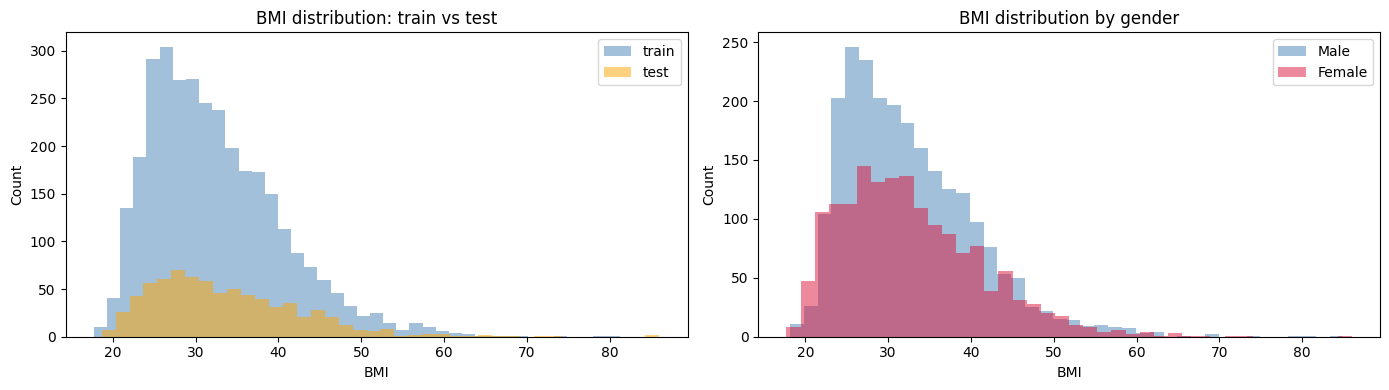


BMI summary by split:
              count       mean       std        min        25%        50%  \
is_training                                                                 
0             752.0  33.698354  9.219863  18.651020  26.872880  31.947427   
1            3210.0  32.434370  8.017202  17.716216  26.317568  30.996473   

                   75%        max  
is_training                        
0            38.867300  85.987061  
1            37.118916  81.211930  

BMI summary by gender:
         count       mean       std        min        25%        50%  \
gender                                                                 
Female  1608.0  32.774600  8.624946  17.716216  26.328712  31.474208   
Male    2354.0  32.605749  8.024122  18.129339  26.454313  31.001126   

              75%        max  
gender                        
Female  37.769732  85.987061  
Male    37.281487  84.984889  


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram comparison
axes[0].hist(df[df['is_training']==1]['bmi'], bins=40, alpha=0.5, label='train', color='steelblue')
axes[0].hist(df[df['is_training']==0]['bmi'], bins=40, alpha=0.5, label='test', color='orange')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Count')
axes[0].set_title('BMI distribution: train vs test')
axes[0].legend()

# Same thing broken down by gender
for gender, color in [('Male', 'steelblue'), ('Female', 'crimson')]:
    subset = df[df['gender']==gender]['bmi']
    axes[1].hist(subset, bins=40, alpha=0.5, label=gender, color=color)
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Count')
axes[1].set_title('BMI distribution by gender')
axes[1].legend()

plt.tight_layout()
plt.show()

# Numerical summary
print('\nBMI summary by split:')
print(df.groupby('is_training')['bmi'].describe())
print('\nBMI summary by gender:')
print(df.groupby('gender')['bmi'].describe())

## Cell 7: Check image dimensions across the whole dataset

We checked one image's size. But are they all that size? If 95% are 224x224 and 5% are 800x600, our preprocessing pipeline needs to handle that.

This loops through every image and grabs its dimensions. It's a bit slow (~1-2 minutes since reading from Drive over network) but you only do it once.

**Why we don't load full pixel data here:** `Image.open` is lazy. It only reads the file header to get dimensions — it doesn't load the actual pixel data unless you ask. So this loop is much faster than "loading all 4,206 images."

In [24]:
from tqdm import tqdm  # tqdm is a progress bar; saves you wondering if anything is happening

widths, heights, modes = [], [], []

for fname in tqdm(df['name'].tolist(), desc='Reading image headers'):
    img = Image.open(f'{IMAGES_DIR}/{fname}')
    widths.append(img.size[0])
    heights.append(img.size[1])
    modes.append(img.mode)

df['width']  = widths
df['height'] = heights
df['mode']   = modes

print('Width stats:')
print(df['width'].describe())
print('\nHeight stats:')
print(df['height'].describe())
print('\nColor modes:')
print(df['mode'].value_counts())
print('\nAre all images square?')
print((df['width'] == df['height']).value_counts())

Reading image headers: 100%|██████████| 3962/3962 [22:31<00:00,  2.93it/s]

Width stats:
count    3962.00000
mean      293.39475
std       170.87321
min        41.00000
25%       159.00000
50%       249.00000
75%       392.00000
max       900.00000
Name: width, dtype: float64

Height stats:
count    3962.000000
mean      364.522211
std       221.003839
min        52.000000
25%       193.000000
50%       306.000000
75%       482.000000
max      1222.000000
Name: height, dtype: float64

Color modes:
mode
RGB    3954
P         8
Name: count, dtype: int64

Are all images square?
False    3939
True       23
Name: count, dtype: int64


## Cell 8: Save the enriched CSV for later phases

We've added some useful columns (`file_exists`, `width`, `height`, `mode`). Save the enriched dataframe so Phase 2 can load it without re-running these checks.

We'll also do one last leakage check — confirm no image filename appears in both train and test. This should always be True (filenames are unique IDs) but it's a 1-line confirmation that the split is clean at least at the filename level.

In [25]:
# Leakage check at the filename level
train_names = set(df[df['is_training']==1]['name'])
test_names  = set(df[df['is_training']==0]['name'])
overlap = train_names & test_names
print(f'Filenames in both train AND test: {len(overlap)} (should be 0)')

# Save enriched metadata
out_path = f'{DATA_DIR}/data_enriched.csv'
df.to_csv(out_path)
print(f'\nSaved enriched metadata to: {out_path}')
print(f'Final shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Filenames in both train AND test: 0 (should be 0)

Saved enriched metadata to: /content/drive/MyDrive/Colab Notebooks/uChicago/ML/ML Final/Data/data_enriched.csv
Final shape: (3962, 8)
Columns: ['bmi', 'gender', 'is_training', 'name', 'file_exists', 'width', 'height', 'mode']


## What you should see when this notebook finishes cleanly

- 4,206 rows, 0 missing files, 0 nulls in core columns
- BMI roughly between 17 and 86, mean around 32
- All (or nearly all) images in RGB mode
- Train and test BMI distributions look similar in shape
- 0 filename overlap between train and test

## Things that might go wrong, and what they mean

- **"file_exists is False for many rows"** → your Drive folder structure doesn't match what the notebook expects. Adjust `IMAGES_DIR`.
- **"some images are mode 'L' (grayscale) or 'RGBA'"** → not a problem now, but Phase 2 needs to convert them to RGB before feeding the model. We'll handle that explicitly.
- **"image sizes vary wildly"** → also fine, Phase 2 will resize everything to 224x224. But if some are tiny (<50 pixels), we should look at them — that suggests bad face crops.
- **"train and test BMI distributions look very different"** → could indicate a non-random split. Worth investigating but probably not project-breaking.

## Next: Phase 2

Once this notebook runs cleanly end-to-end, ping me and we'll start Phase 2 (feature extraction with a pre-trained face model). I'll write that as a separate notebook.